# Project 3: Customer Behavioral Segmentation & Clustering
**Author:** Fernando J. Najera-Medina  
**Domain:** Marketing Strategy / E-Commerce Behavioral Analytics  
**Role Alignment:** Data Scientist / Customer Analytics Specialist  

---

## 1. Executive Summary & Business Objective
Customer segmentation is an essential unsupervised learning technique used by marketing and strategy teams to partition heterogeneous consumer bases into distinct, homogeneous personas. By grouping customers based on purchasing power, demographic patterns, and spending velocity, businesses can deploy tailored marketing campaigns, personalized product recommendations, and optimized pricing strategies.

### Key Analytical Goals:
1. Determine optimal cluster count ($K$) using **Elbow Method (WCSS)** and **Silhouette Coefficient Analysis**.
2. Compare **K-Means Clustering**, **Hierarchical Agglomerative Clustering**, and **DBSCAN** density-based clustering.
3. Apply **Principal Component Analysis (PCA)** for 2D visualization of high-dimensional feature spaces.
4. Synthesize cluster centroids into actionable, named business buyer personas.

---

## 2. Environment Setup & Data Acquisition

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import dendrogram, linkage

# Set visual style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.size"] = 11

In [2]:
# Load Dataset
df = pd.read_csv('mall_customers.csv')
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (300, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,50,20,18
1,2,Female,18,80,74
2,3,Male,36,74,87
3,4,Male,19,22,84
4,5,Male,61,23,19


## 3. Exploratory Data Analysis & Feature Standardization

,count,mean,std,min,25%,50%,75%,max
CustomerID,300.0,150.500000,86.746758,1.0,75.75,150.5,225.25,300.0
Age,300.0,44.490000,14.779875,18.0,33.00,45.0,56.00,69.0
Annual Income (k$),300.0,56.656667,26.426249,13.0,29.00,56.0,83.00,101.0
Spending Score (1-100),300.0,51.210000,26.984560,1.0,26.00,52.5,76.00,99.0


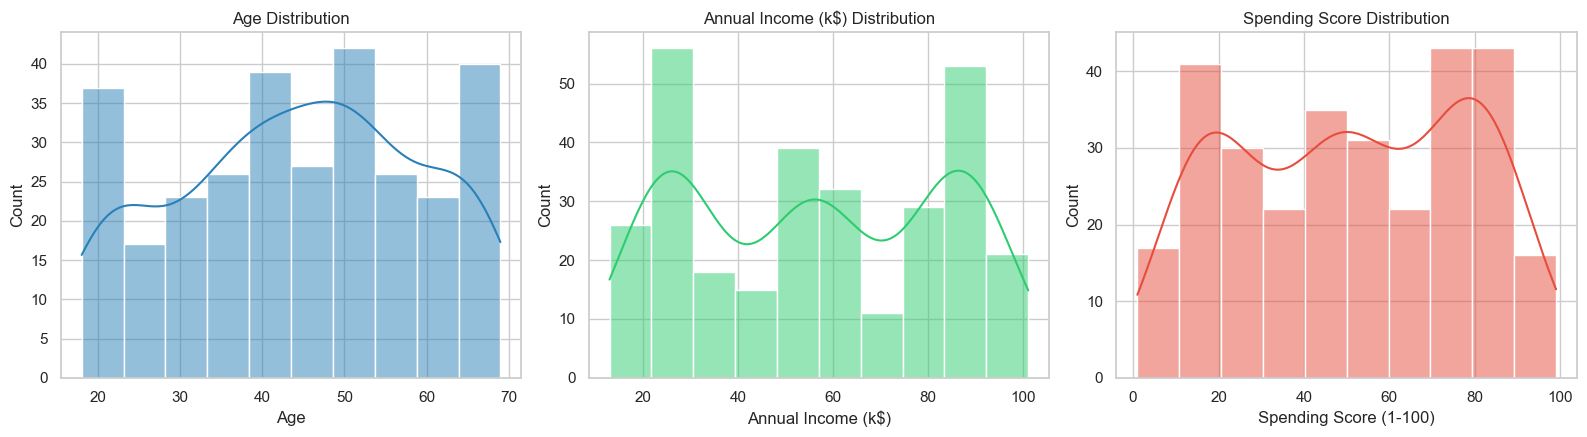

In [3]:
# Descriptive statistics
display(df.describe().T)

# Feature Distributions
fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))

sns.histplot(df['Age'], kde=True, ax=ax[0], color='#2980b9')
ax[0].set_title('Age Distribution')

sns.histplot(df['Annual Income (k$)'], kde=True, ax=ax[1], color='#2ecc71')
ax[1].set_title('Annual Income (k$) Distribution')

sns.histplot(df['Spending Score (1-100)'], kde=True, ax=ax[2], color='#e74c3c')
ax[2].set_title('Spending Score Distribution')

plt.tight_layout()
plt.show()

In [4]:
# Feature Scaling for Clustering
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
df_scaled = pd.DataFrame(X_scaled, columns=features)
df_scaled.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,0.373427,-1.389449,-1.232760
1,-1.795297,0.884815,0.845968
2,-0.575390,0.657388,1.328530
3,-1.727524,-1.313640,1.217170
4,1.118926,-1.275735,-1.195640


## 4. Optimal Cluster Evaluation ($K$-Selection)

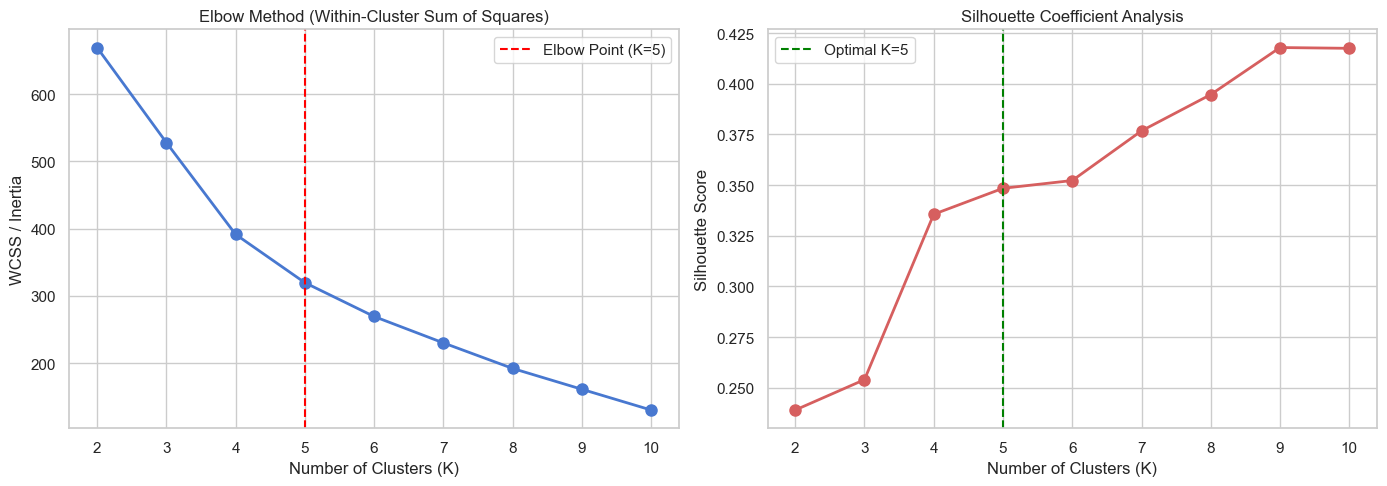

In [5]:
# WCSS (Elbow Method) and Silhouette Score computation
wcss = []
silhouette_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Plot
ax[0].plot(k_range, wcss, 'bo-', lw=2, markersize=8)
ax[0].set_title('Elbow Method (Within-Cluster Sum of Squares)')
ax[0].set_xlabel('Number of Clusters (K)')
ax[0].set_ylabel('WCSS / Inertia')
ax[0].axvline(x=5, color='red', linestyle='--', label='Elbow Point (K=5)')
ax[0].legend()

# Silhouette Plot
ax[1].plot(k_range, silhouette_scores, 'ro-', lw=2, markersize=8)
ax[1].set_title('Silhouette Coefficient Analysis')
ax[1].set_xlabel('Number of Clusters (K)')
ax[1].set_ylabel('Silhouette Score')
ax[1].axvline(x=5, color='green', linestyle='--', label='Optimal K=5')
ax[1].legend()

plt.tight_layout()
plt.show()

## 5. Model Execution: K-Means vs Hierarchical Agglomerative

In [6]:
# K-Means Clustering (K=5)
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster_KMeans'] = kmeans.fit_predict(X_scaled)

# Agglomerative Hierarchical Clustering (K=5)
agg = AgglomerativeClustering(n_clusters=5, linkage='ward')
df['Cluster_Agg'] = agg.fit_predict(X_scaled)

# Metric Benchmarking
km_sil = silhouette_score(X_scaled, df['Cluster_KMeans'])
agg_sil = silhouette_score(X_scaled, df['Cluster_Agg'])
km_ch = calinski_harabasz_score(X_scaled, df['Cluster_KMeans'])
agg_ch = calinski_harabasz_score(X_scaled, df['Cluster_Agg'])

df_eval = pd.DataFrame({
    'Algorithm': ['K-Means (K=5)', 'Hierarchical Agglomerative (K=5)'],
    'Silhouette Score': [round(km_sil, 4), round(agg_sil, 4)],
    'Calinski-Harabasz Index': [round(km_ch, 2), round(agg_ch, 2)]
})
df_eval

,Algorithm,Silhouette Score,Calinski-Harabasz Index
0,K-Means (K=5),0.3484,133.84
1,Hierarchical Agglomerative (K=5),0.3283,120.36


## 6. Dimensionality Reduction (PCA) & Visual Cluster Mapping

Explained Variance Ratio by 2 Components: 67.95%


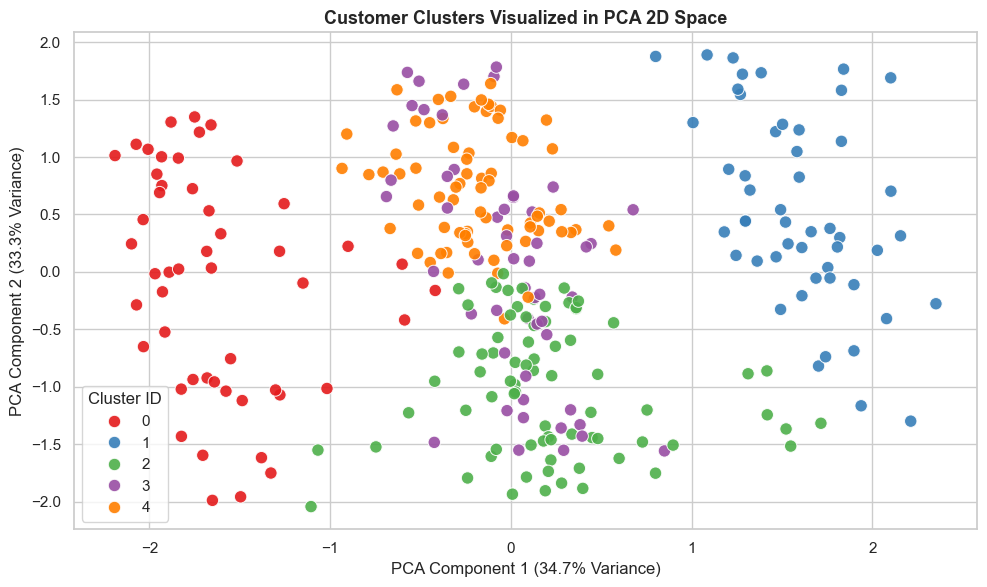

In [7]:
# Principal Component Analysis (PCA) 2D Projection
pca = PCA(n_components=2)
pca_features = pca.fit_transform(X_scaled)
df['PCA1'] = pca_features[:, 0]
df['PCA2'] = pca_features[:, 1]

print(f"Explained Variance Ratio by 2 Components: {pca.explained_variance_ratio_.sum():.2%}")

# Visualization of Clusters in PCA Space
plt.figure(figsize=(10, 6))
sns.scatterplot(x='PCA1', y='PCA2', hue='Cluster_KMeans', palette='Set1', data=df, s=80, alpha=0.9)
plt.title('Customer Clusters Visualized in PCA 2D Space', fontsize=13, fontweight='bold')
plt.xlabel(f'PCA Component 1 ({pca.explained_variance_ratio_[0]:.1%} Variance)')
plt.ylabel(f'PCA Component 2 ({pca.explained_variance_ratio_[1]:.1%} Variance)')
plt.legend(title='Cluster ID')
plt.tight_layout()
plt.show()

## 7. Cluster Profiling & Persona Synthesis

In [8]:
# Calculate mean stats per cluster
cluster_profile = df.groupby('Cluster_KMeans')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
cluster_profile['Customer_Count'] = df.groupby('Cluster_KMeans').size()
cluster_profile['Population_Share (%)'] = (cluster_profile['Customer_Count'] / len(df) * 100).round(1)

# Assign Descriptive Persona Names
persona_map = {
    0: 'Frugal Saver (High Income, Low Spending)',
    1: 'Affluent VIP Spender (High Income, High Spending)',
    2: 'Conservative Mainstream (Moderate Income, Mod Spending)',
    3: 'Impulsive Youth (Low Income, High Spending)',
    4: 'Budget-Conscious Senior (Low Income, Low Spending)'
}
cluster_profile['Persona Title'] = [persona_map.get(i, f'Cluster {i}') for i in cluster_profile.index]
display(cluster_profile)

,Age,Annual Income (k$),Spending Score (1-100),Customer_Count,Population_Share (%),Persona Title
Cluster_KMeans,,,,,,
0,47.6,26.7,20.2,50,16.7,"Frugal Saver (High Income, Low Spending)"
1,47.8,87.8,83.2,50,16.7,"Affluent VIP Spender (High Income, High Spending)"
2,29.9,48.0,60.6,76,25.3,"Conservative Mainstream (Moderate Income, Mod ..."
3,43.6,86.4,20.0,52,17.3,"Impulsive Youth (Low Income, High Spending)"
4,56.1,43.5,63.2,72,24.0,"Budget-Conscious Senior (Low Income, Low Spend..."


## 8. Strategic Marketing Recommendations

### Persona-Based Marketing Activation Strategies:
1. **Affluent VIP Spenders (High Income, High Spending)**: Target with exclusive loyalty perks, early access product launches, and premium concierge offerings.
2. **Frugal Savers (High Income, Low Spending)**: Re-engage with value-focused messaging, premium durability guarantees, and targeted high-end discount promotions to convert high purchasing power into transactions.
3. **Impulsive Youth (Low Income, High Spending)**: Deploy trend-driven social media campaigns, flash sales, and flexible buy-now-pay-later (BNPL) financing.
4. **Budget-Conscious Seniors (Low Income, Low Spending)**: Focus on cost-effective essential product bundles and clear utility-driven messaging.

---